In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib
import varray as va
import ldax_analysis as lan
from matplotlib.patches import Ellipse
from scipy.optimize import curve_fit
import tqdm
import processingFunctions
plt.style.use('../style.mplstyle')
rq_path = '/mnt/drive2/TPC_RQs/proc_settings_amp50V_v004dope/'

#Enter what data sets you want to analyze followed by number of files to process
dates = [
    '2026-07-28-0917,50',
    '2026-07-28-1239,50',
    '2026-07-28-1636,50',
    '2026-07-28-1636,50-100',
    '2026-07-28-1636,100-150',
    '2026-07-28-1636,150-200',
    '2026-07-28-1636,200-250',
    '2026-07-29-0839,50',
    '2026-07-31-0910,50',
    '2026-07-31-0910,50-100',
         ]
dataset_labels = [
    '2026-07-28-0917',
    '2026-07-28-1239',
    '2026-07-28-1636pt1',
    '2026-07-28-1636pt2',
    '2026-07-28-1636pt3',
    '2026-07-28-1636pt4',
    '2026-07-28-1636pt5',
    '2026-07-29-0839',
    '2026-07-31-0910pt1',
    '2026-07-31-0910pt2',
]

rq_names = [
    'ss_s1_phe_ch',
    'ss_s1_phe',
    'ss_s1_aft',
    'ss_s1_mhf',
    'ss_s2_phe_ch',
    'ss_s2_phe',
    'ss_s2_aft',
    'ss_s2_x_raw',
    'ss_s2_y_raw',
    'ss_s2_r_raw',
    'ss_s2_drift_time',
    'ss_bad_phe',
    'ss_e_timestamps'
]

In [3]:
#Collect all data from selected files and store them in dict
d = processingFunctions.get_all_data(dates, dataset_labels, rq_path, rq_names)

Finished collecting data for 2026-07-28-0917
Finished collecting data for 2026-07-28-1239
Finished collecting data for 2026-07-28-1636pt1
Finished collecting data for 2026-07-28-1636pt2
Finished collecting data for 2026-07-28-1636pt3
Finished collecting data for 2026-07-28-1636pt4
Finished collecting data for 2026-07-28-1636pt5
Finished collecting data for 2026-07-29-0839
Finished collecting data for 2026-07-31-0910pt1
Finished collecting data for 2026-07-31-0910pt2


In [4]:
for label in dataset_labels:
    dataset = d[label]
    dataset['ss_s2_top_phe'] = np.sum(dataset['ss_s2_phe_ch'][:16], axis=0) #phe
    dataset['ss_s2_bot_phe'] = np.sum(dataset['ss_s2_phe_ch'][-16:], axis=0) #phe
    dataset['ss_s2_tba'] = (dataset['ss_s2_top_phe'] - dataset['ss_s2_bot_phe'])/dataset['ss_s2_phe'] #unitless
    dataset['ss_good_phe'] = dataset['ss_s2_phe'] + dataset['ss_s1_phe'] #phe
    dataset['ss_s2_width595'] = dataset['ss_s2_aft'][6] - dataset['ss_s2_aft'][0] #samples
    dataset['ss_trig_timestamp'] = (dataset['ss_e_timestamps'] - dataset['ss_e_timestamps'][0])*10**-8 #seconds

In [14]:
#Define Cuts
for label in dataset_labels:
    dataset = d[label]
    dataset['drift_time_cut'] = ((dataset['ss_s2_drift_time'] < 750) & (dataset['ss_s2_drift_time'] > 250))
    dataset['radial_cut'] = (dataset['ss_s2_r_raw'] < 3)
    #dataset['pulse_width_cut'] = (dataset['ss_s2_width595'] > 102) & (dataset['ss_s2_width595'] < 160)
    dataset['bad_area_cut'] = ((dataset['ss_bad_phe'] < 0.8*np.log10(dataset['ss_good_phe'])**5) & (dataset['ss_bad_phe'] > 1e-2))
    dataset['tba_cut'] = ((dataset['ss_s2_tba'] < 0.2) & (dataset['ss_s2_tba'] > 0))
    dataset['mhf_cut'] = (dataset['ss_s1_mhf'] < 1.3*dataset['ss_s1_phe']**-0.7+0.05)

/tmp/ipykernel_74825/4236171711.py:7: RuntimeWarning: invalid value encountered in log10
  dataset['bad_area_cut'] = ((dataset['ss_bad_phe'] < 0.8*np.log10(dataset['ss_good_phe'])**5) & (dataset['ss_bad_phe'] > 1e-2))
/tmp/ipykernel_74825/4236171711.py:9: RuntimeWarning: invalid value encountered in power
  dataset['mhf_cut'] = (dataset['ss_s1_mhf'] < 1.3*dataset['ss_s1_phe']**-0.7+0.05)


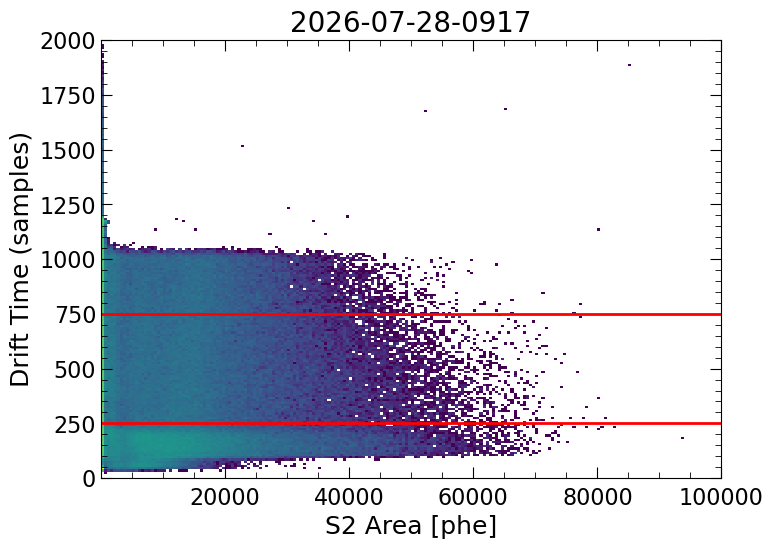

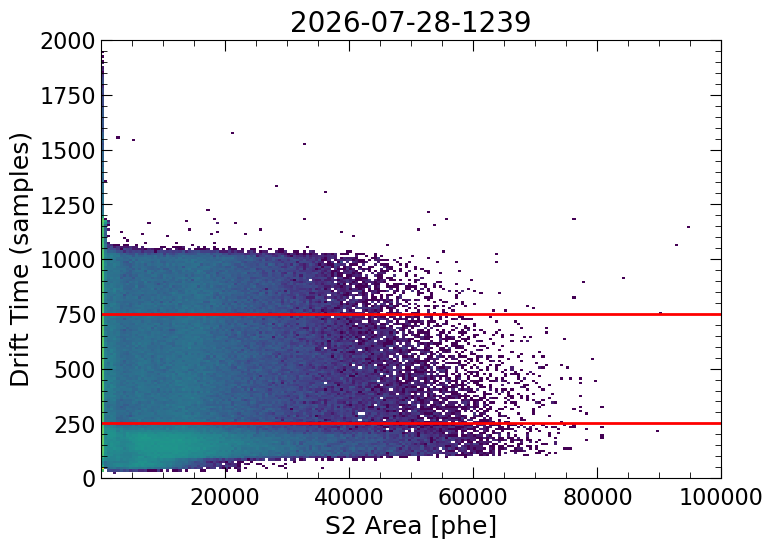

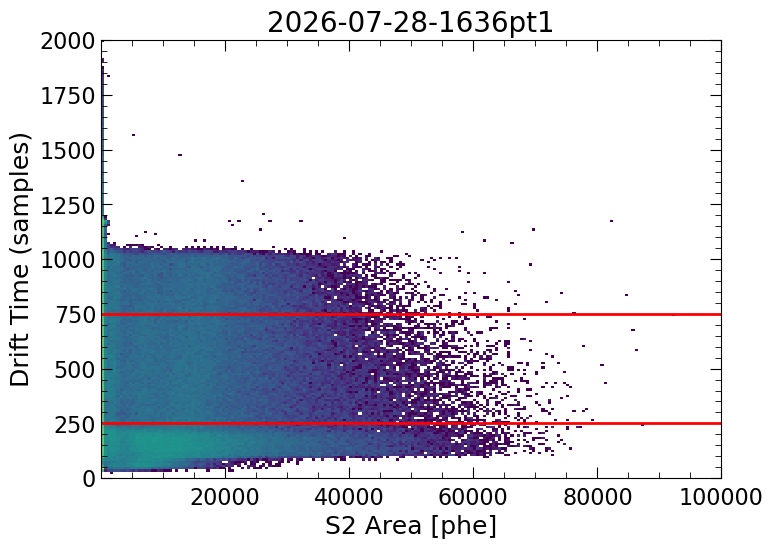

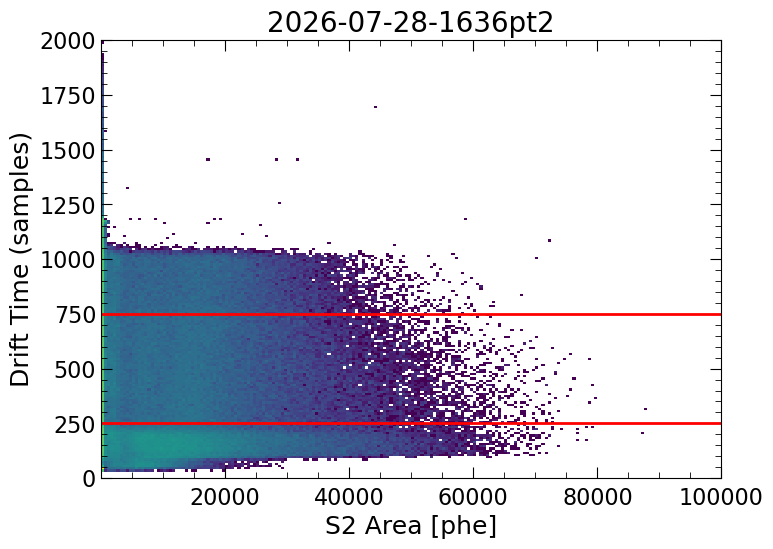

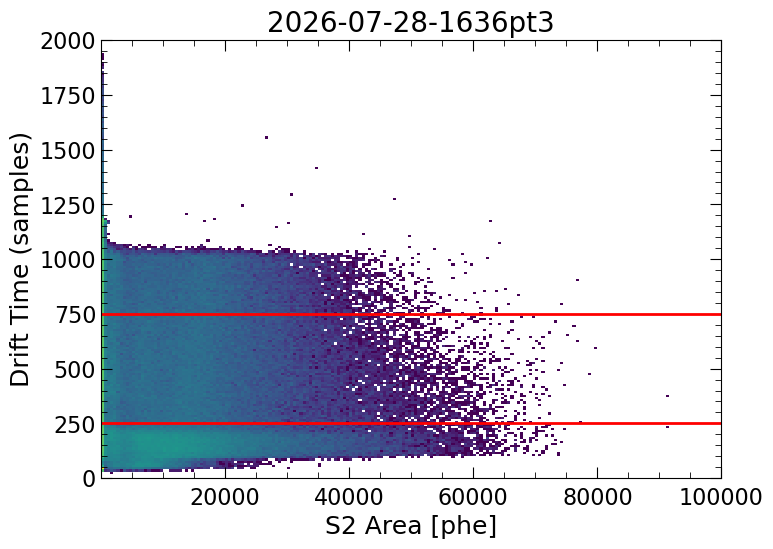

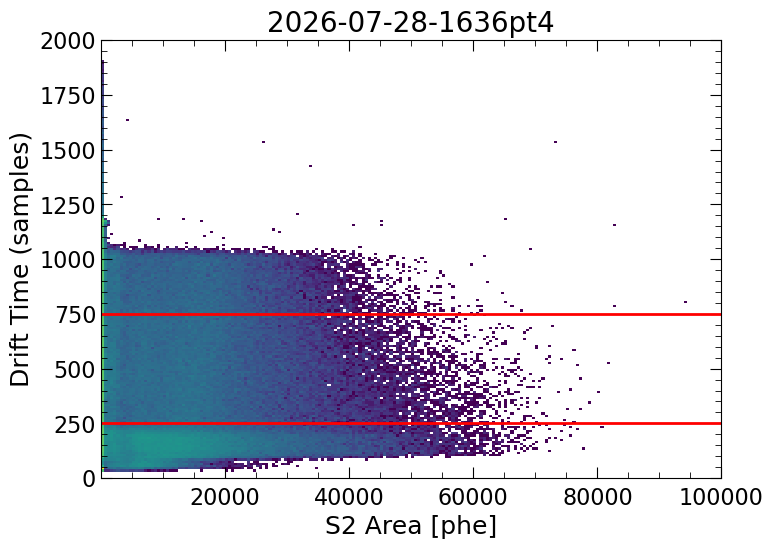

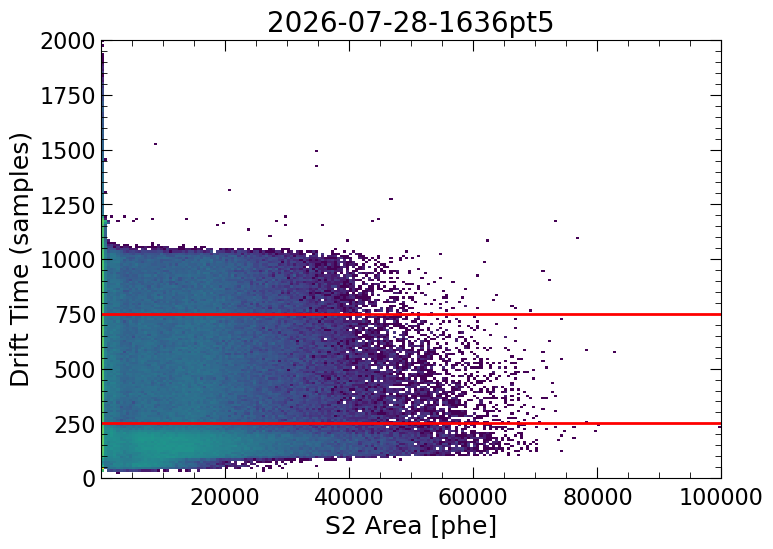

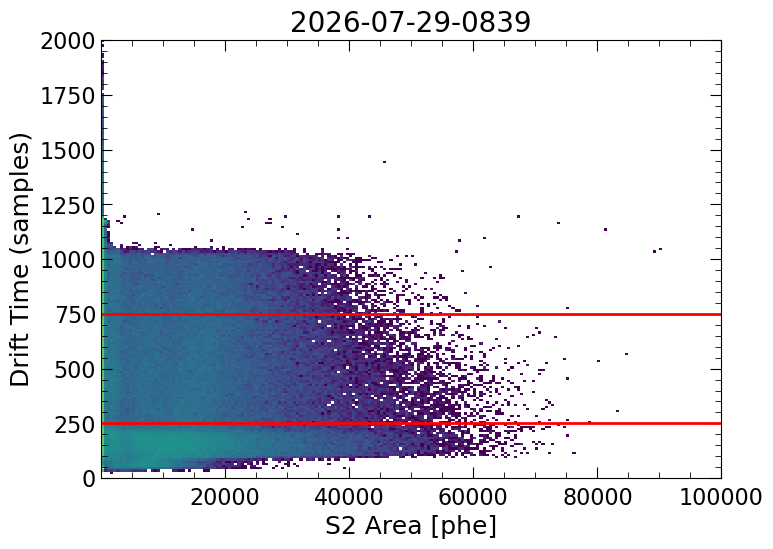

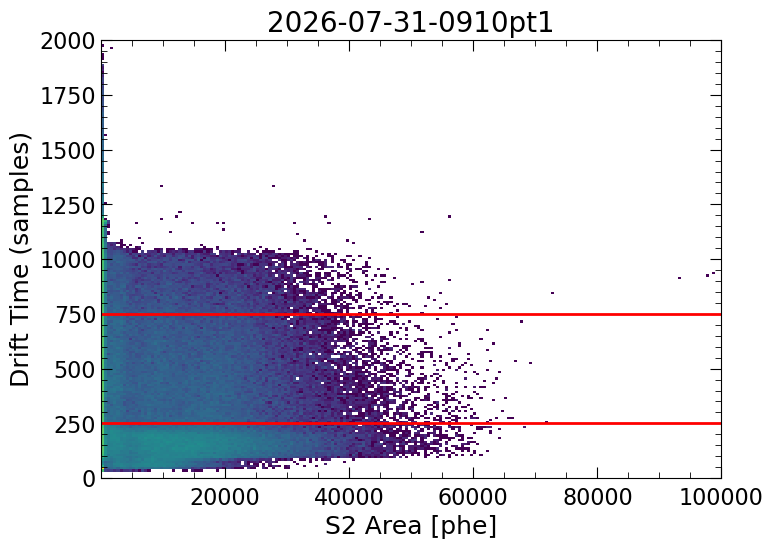

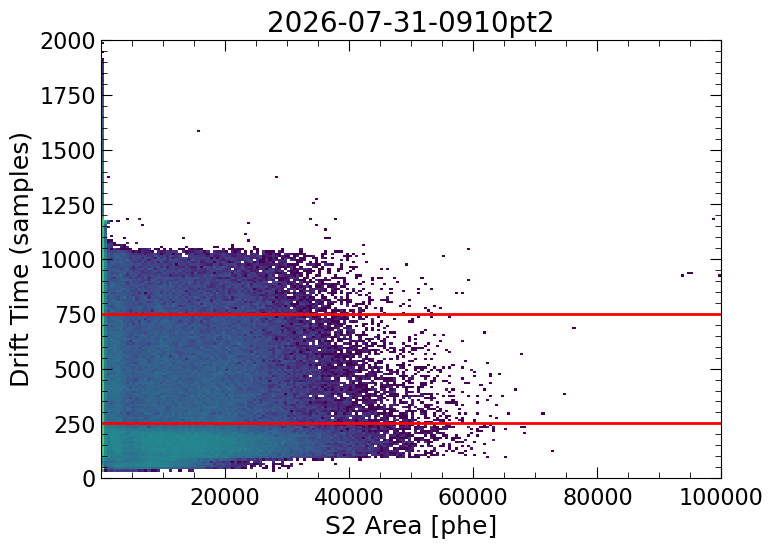

In [12]:
drift_time_cutoffs = [250, 750]

for label in dataset_labels:
    RQs = d
    processingFunctions.plot2d(RQs[label]['ss_s2_phe']* np.exp(RQs[label]['ss_s2_drift_time']/1320), RQs[label]['ss_s2_drift_time'], (1,1e5), (0, 2e3), x_bins=200, y_bins=200, flag_log=True)

    plt.xlabel("S2 Area [phe]")
    plt.ylabel("Drift Time (samples)")
    plt.axhline(y=drift_time_cutoffs[0], color='red')
    plt.axhline(y=drift_time_cutoffs[1], color='red')
    plt.title(label)
    plt.show()
    RQs[label]['drift_time_cut'] = ((RQs[label]['ss_s2_drift_time'] < drift_time_cutoffs[1]) & (RQs[label]['ss_s2_drift_time'] > drift_time_cutoffs[0]))

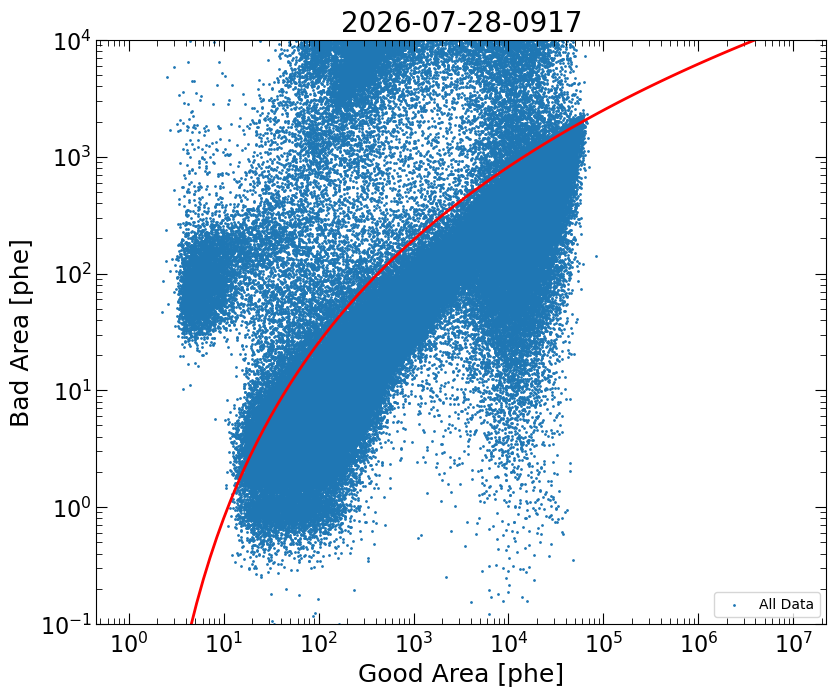

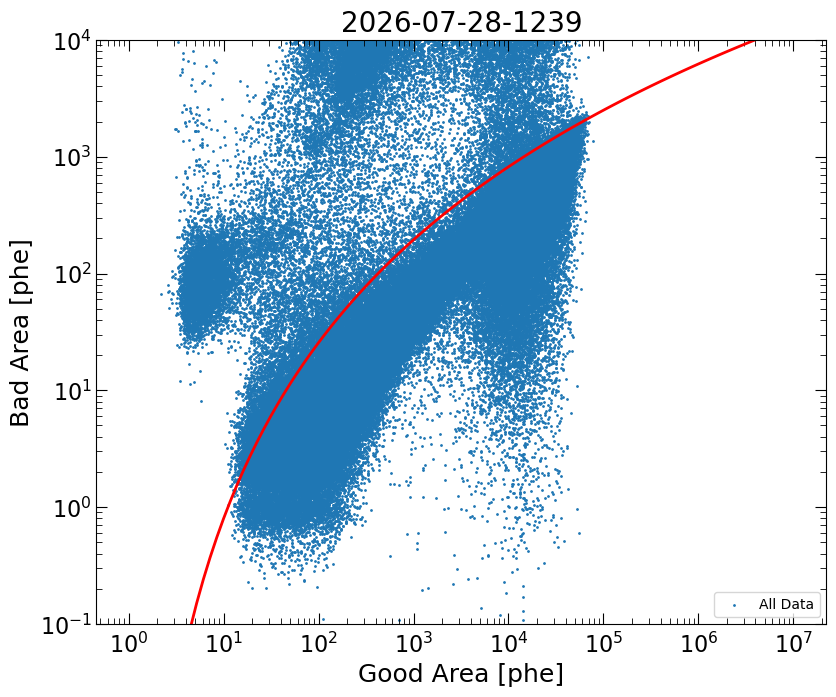

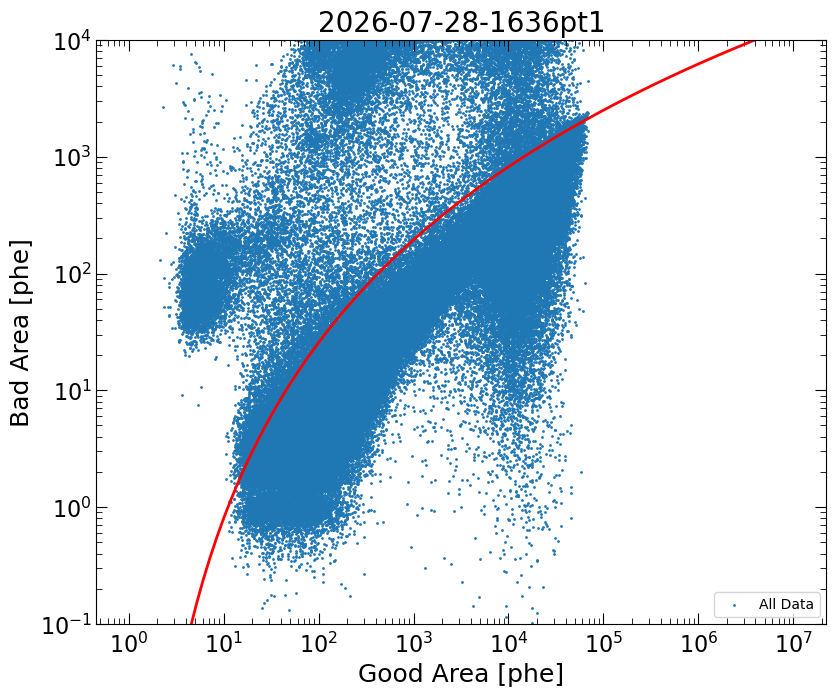

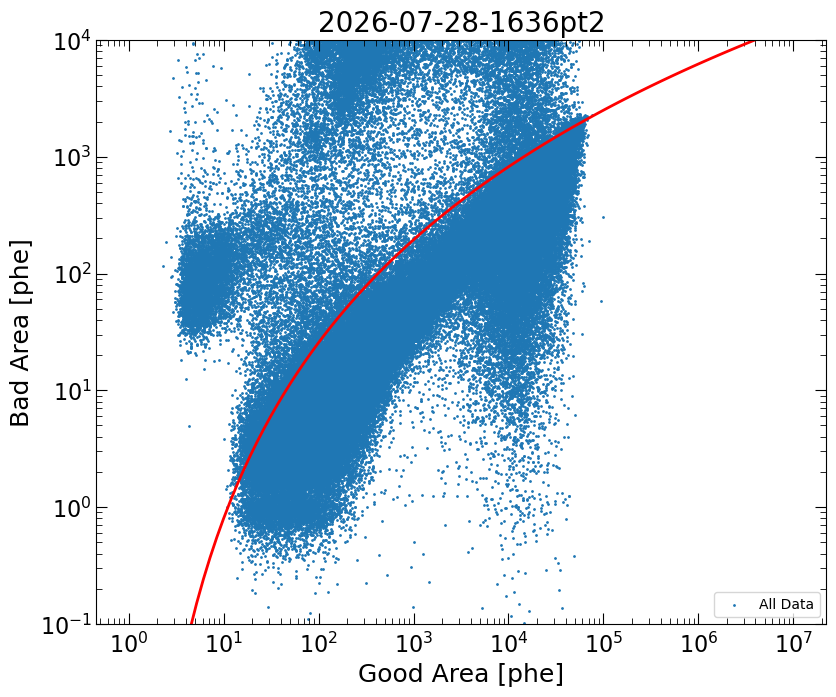

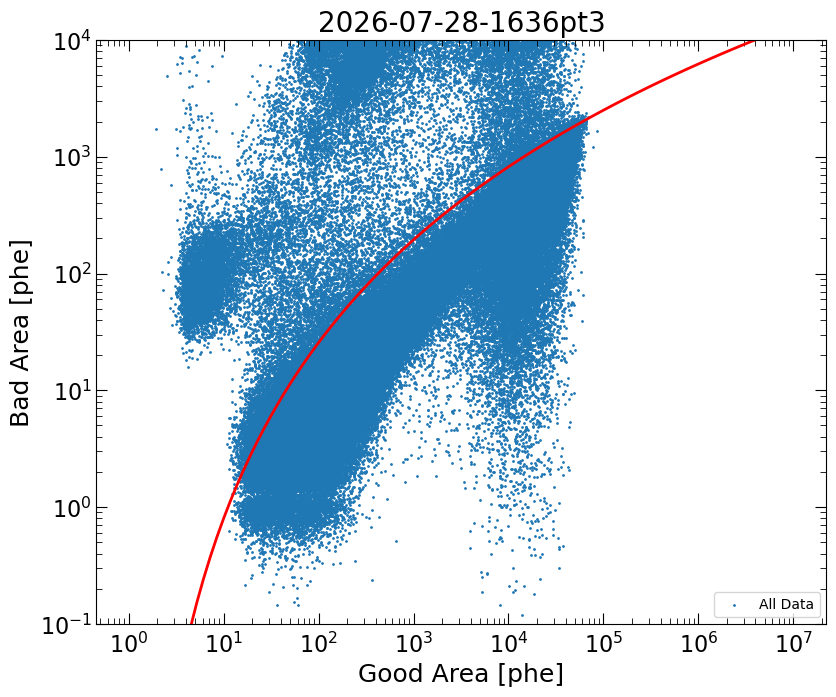

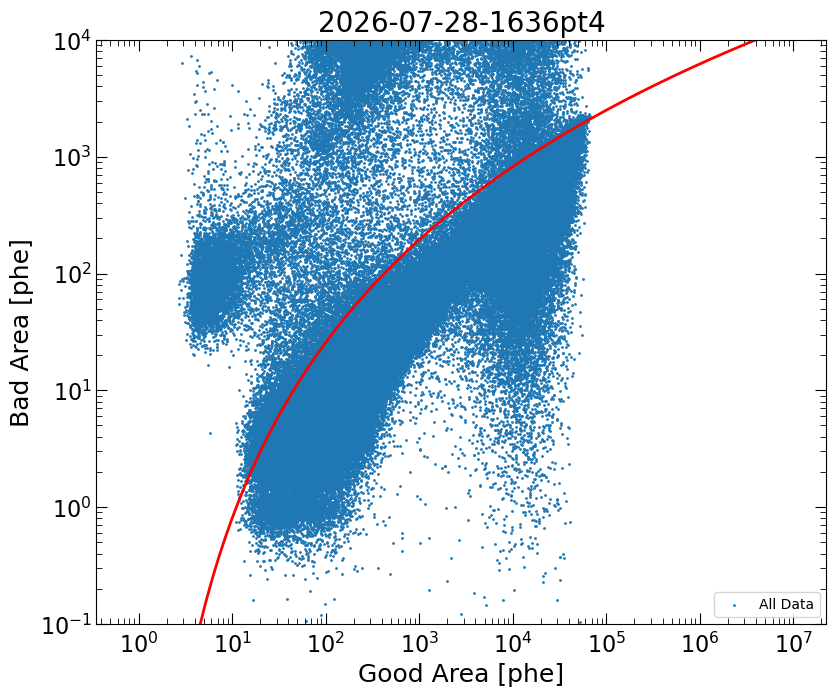

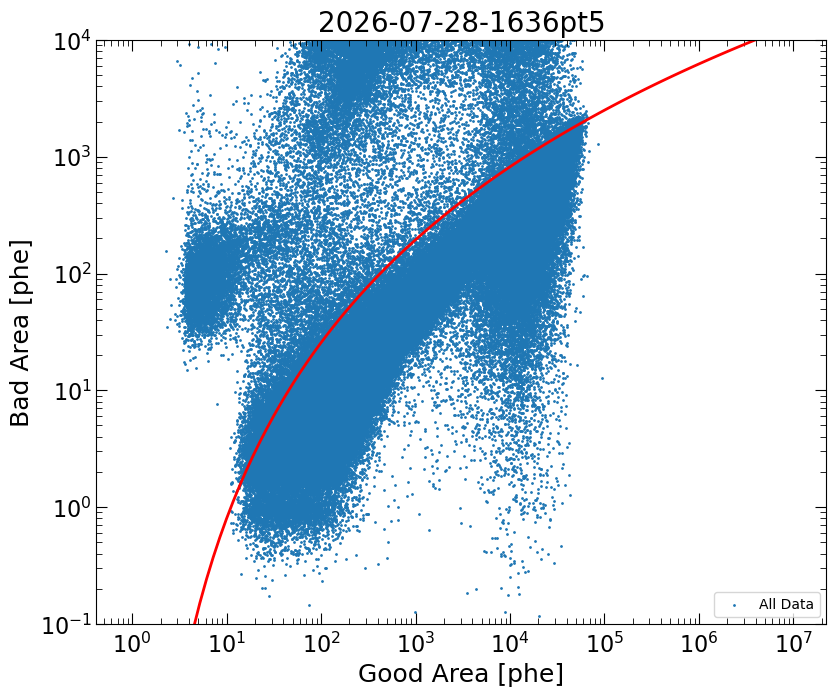

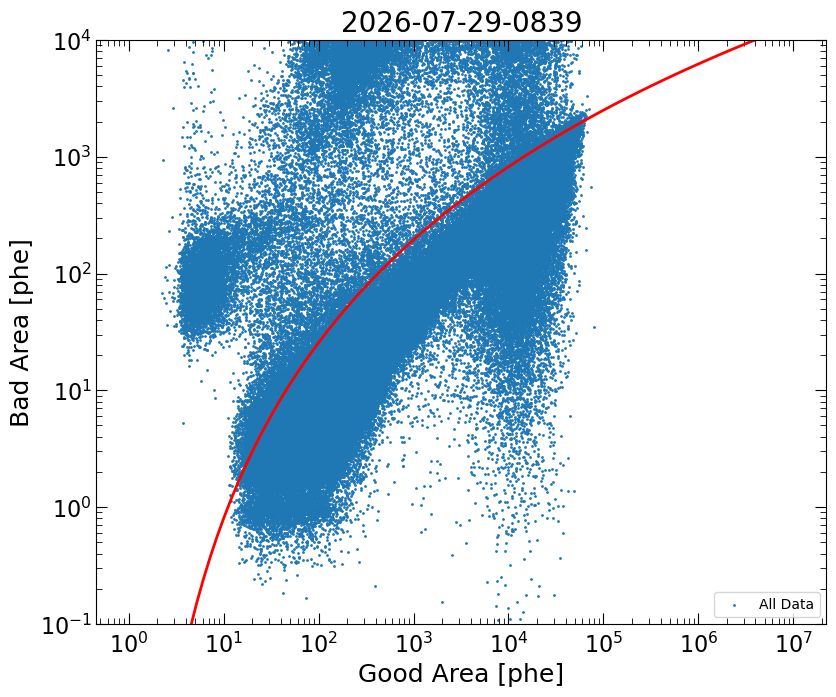

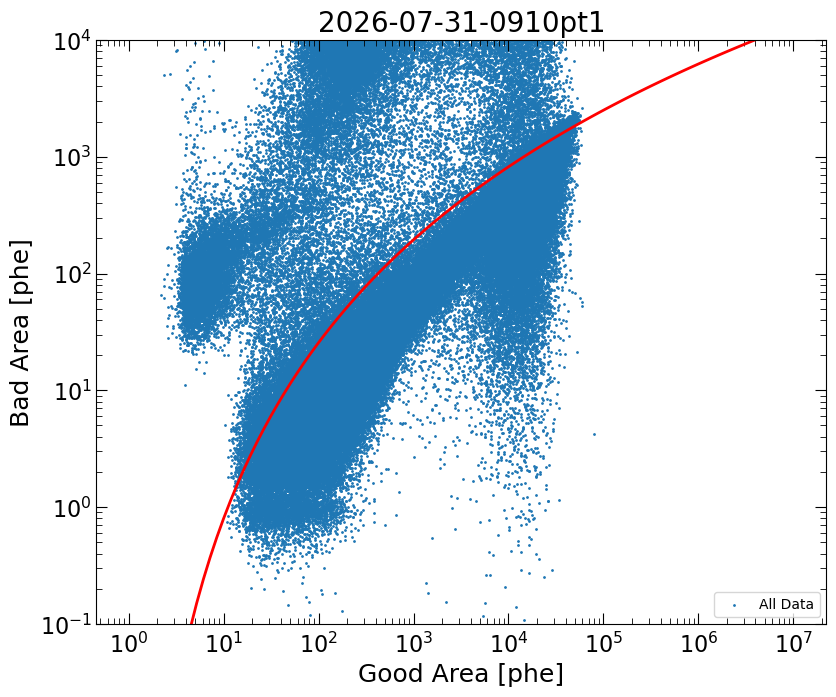

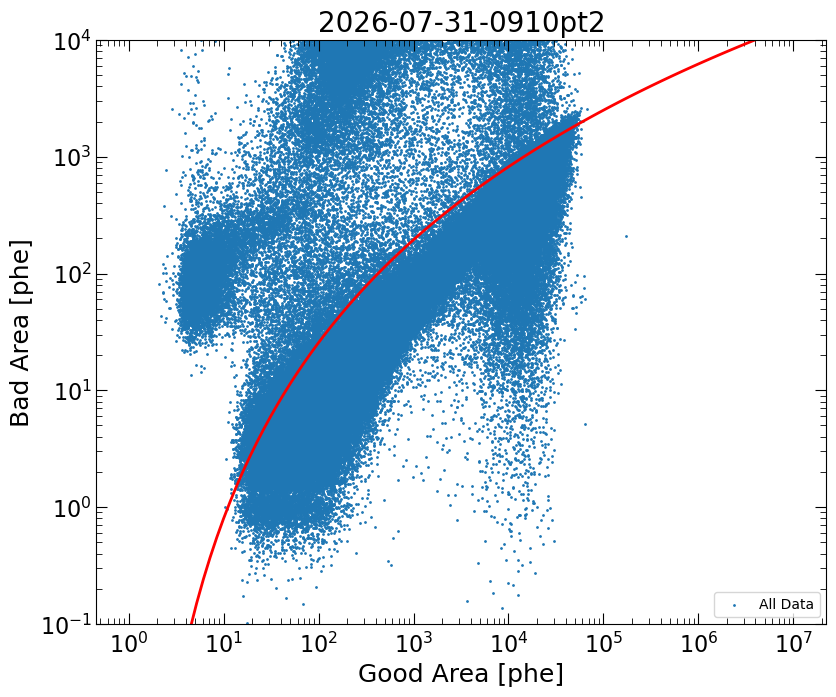

In [7]:
for label in dataset_labels:
    dataset = d[label]
    bad_area = dataset['ss_bad_phe']
    good_area = dataset['ss_good_phe']
    plt.figure(figsize=(10,8))
    plt.scatter(good_area, bad_area, s=1, label='All Data')
    plt.plot(np.logspace(0.01,7,100), 0.8*np.log10(np.logspace(0.01,7,100))**5, color='red')
    plt.legend()
    plt.axhline(y=1e-2, color='red')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Good Area [phe]")
    plt.ylabel("Bad Area [phe]")
    plt.title(label)
    plt.ylim(1e-1, 1e4)
    plt.show()
    #plt.xlim(5e1, 4e2)
    #d['bad_area_cut'] = ((d['ss_bad_phe'] < 0.8*np.log10(d['ss_good_phe'])**5) & (d['ss_bad_phe'] > 1e-2))

/tmp/ipykernel_74825/956272364.py:4: RuntimeWarning: divide by zero encountered in power
  plt.plot(np.linspace(0,1000,100), 1.3*np.linspace(0,1000,100)**-0.7+0.05, color='red')


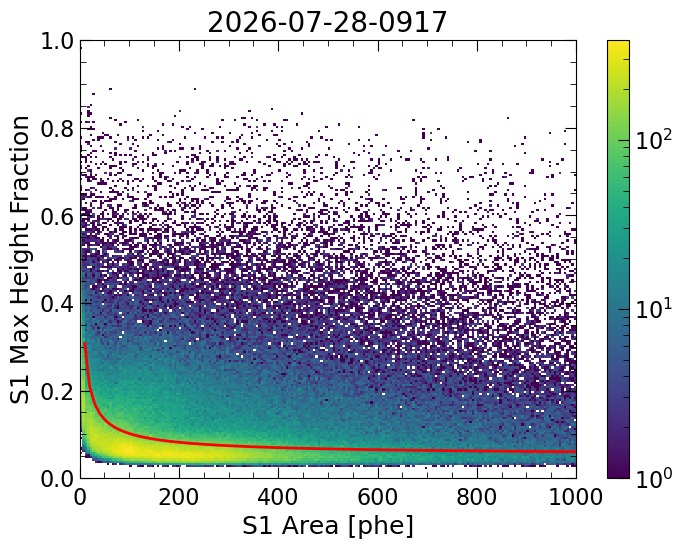

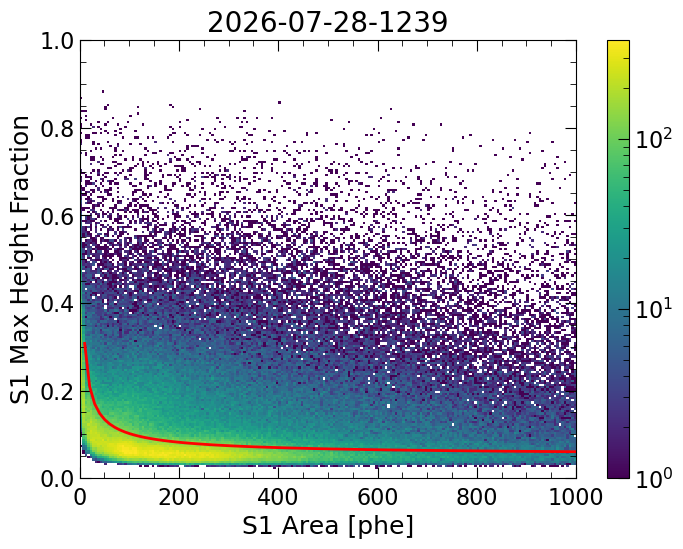

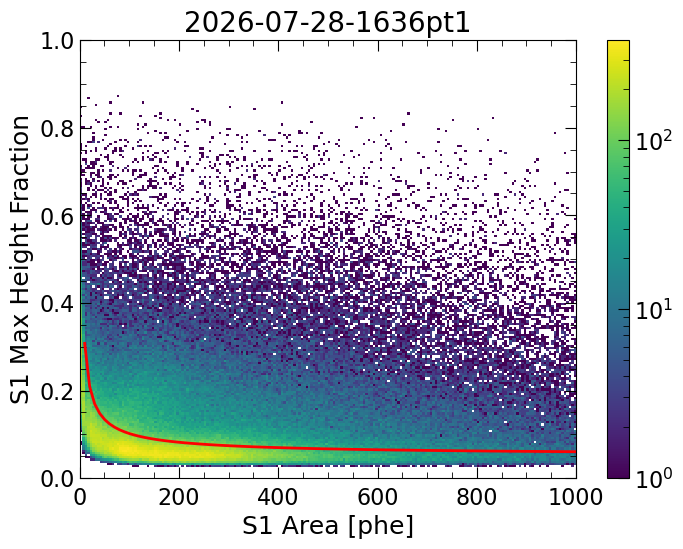

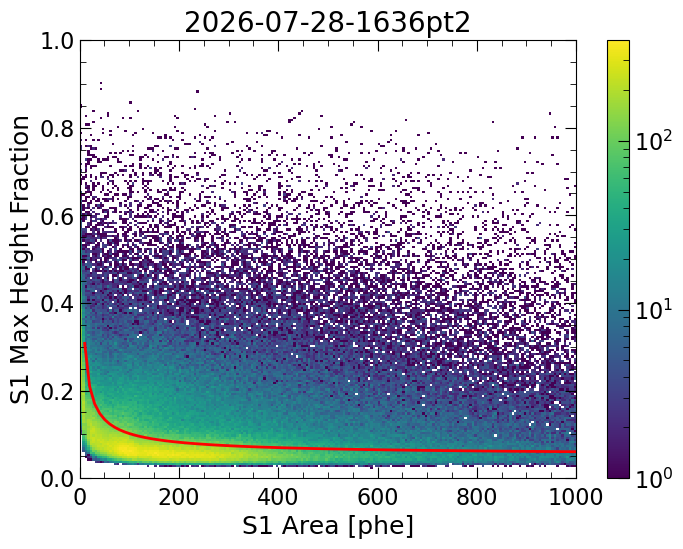

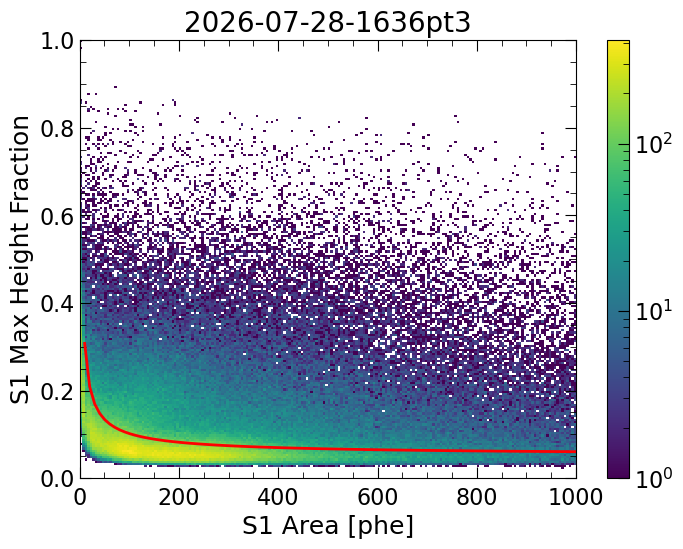

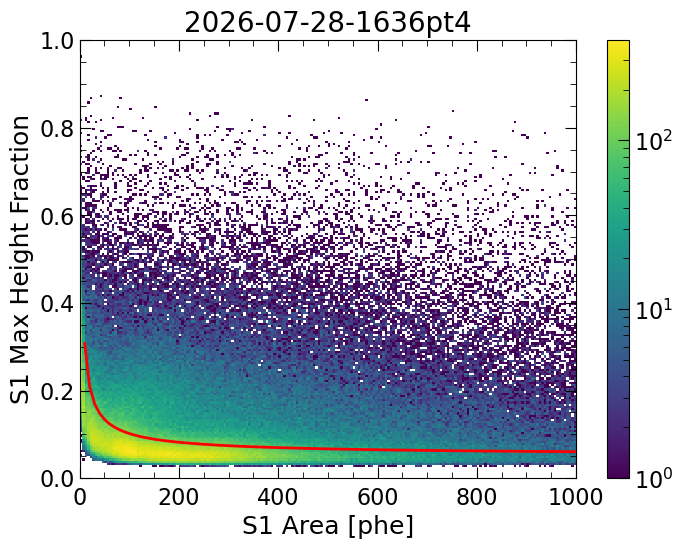

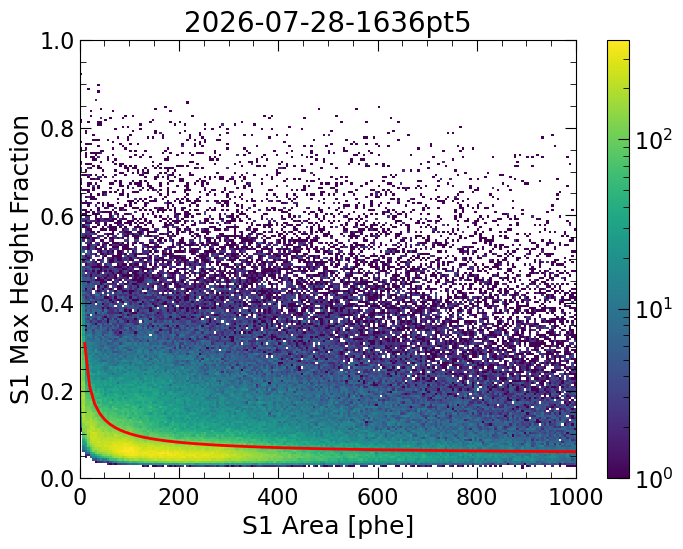

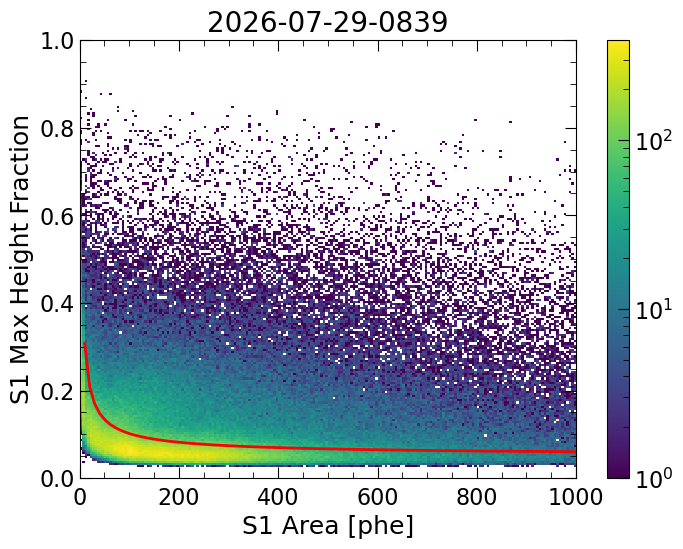

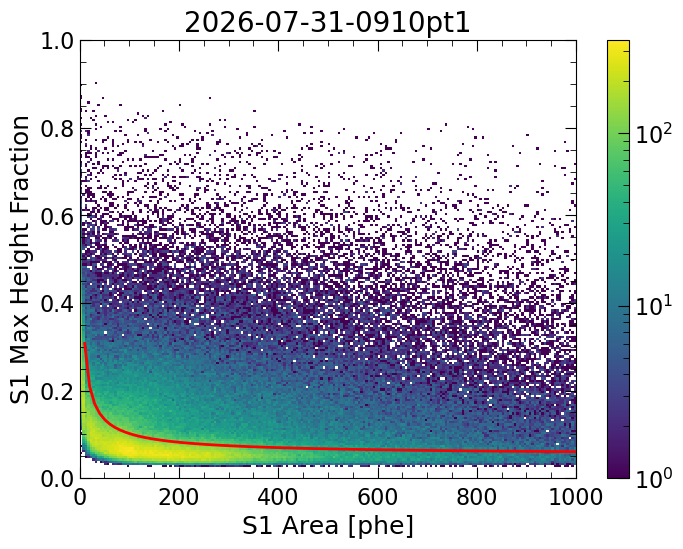

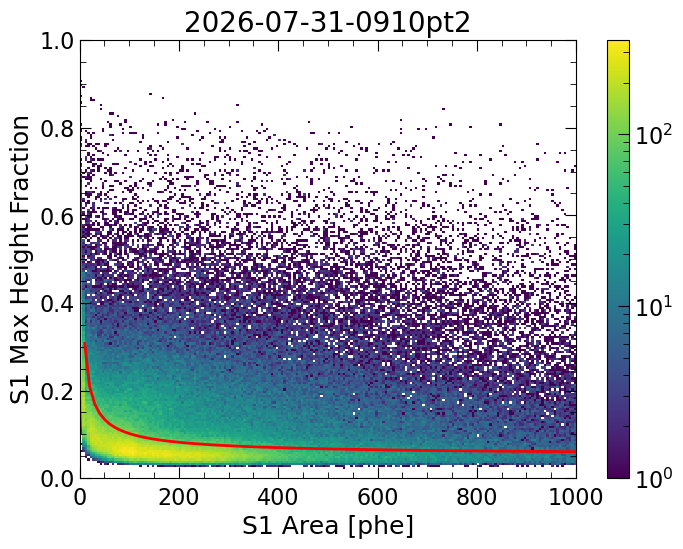

In [8]:
for label in dataset_labels:
    dataset = d[label]
    processingFunctions.plot2d(dataset['ss_s1_phe'], dataset['ss_s1_mhf'], (0,1e3), (0, 1), x_bins=200, y_bins=200, flag_log=True)
    plt.plot(np.linspace(0,1000,100), 1.3*np.linspace(0,1000,100)**-0.7+0.05, color='red')
    plt.xlabel("S1 Area [phe]")
    plt.ylabel("S1 Max Height Fraction")
    plt.title(label)
    plt.colorbar()
    plt.show()


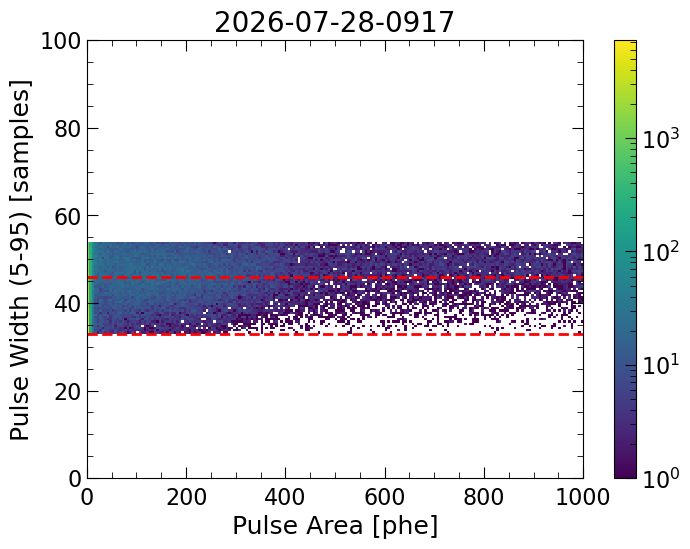

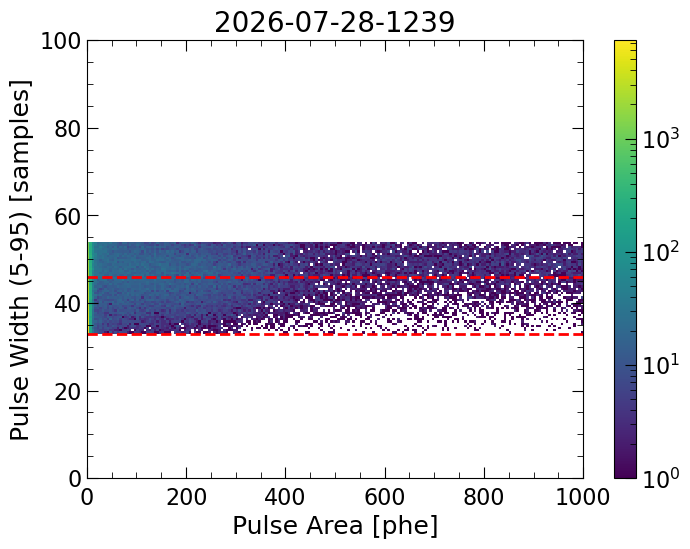

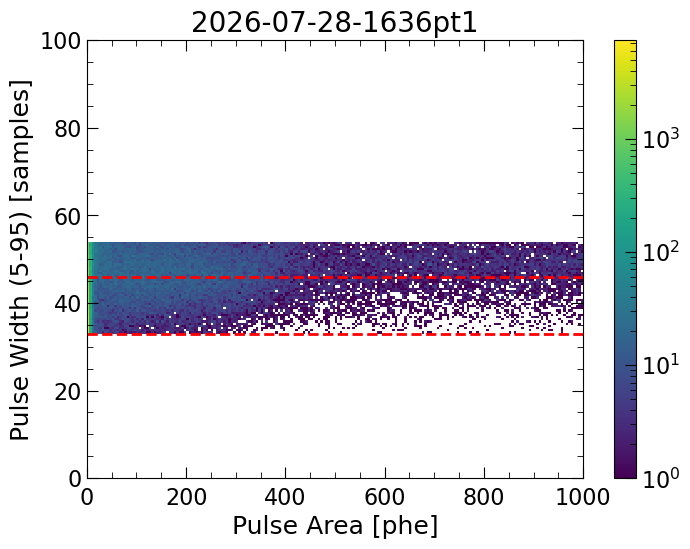

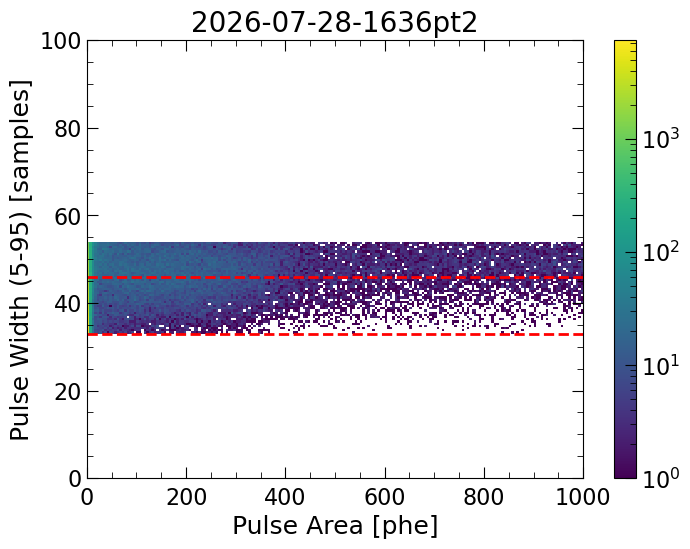

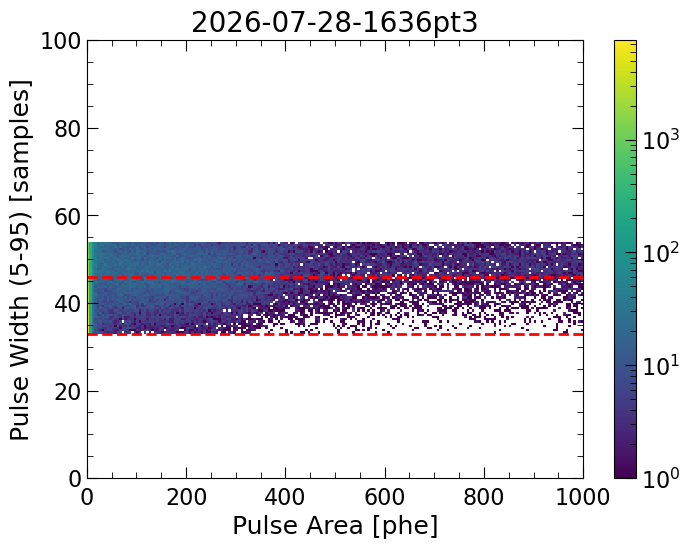

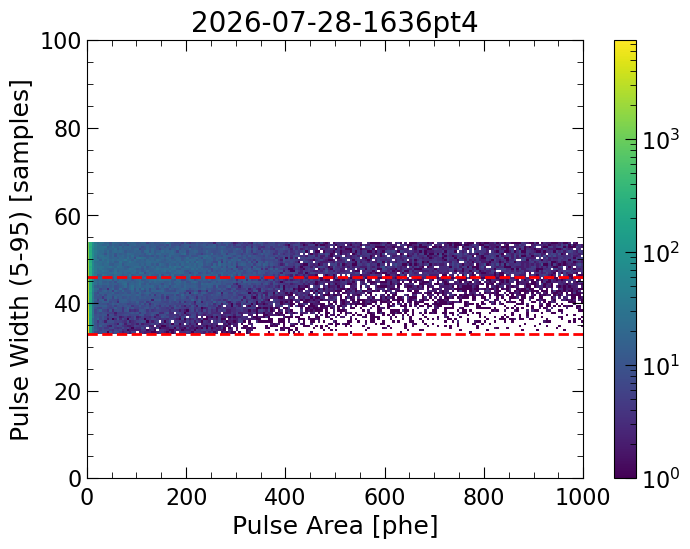

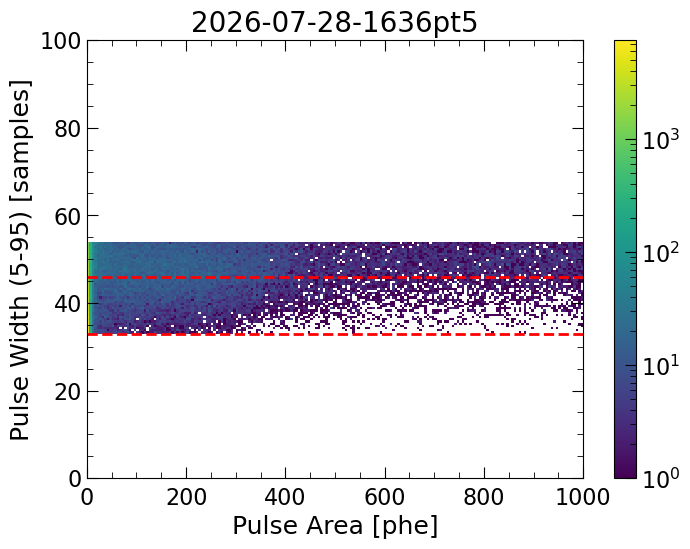

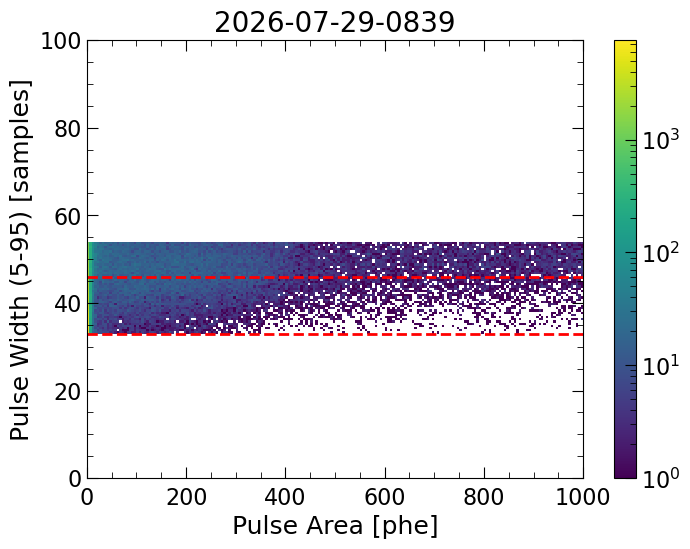

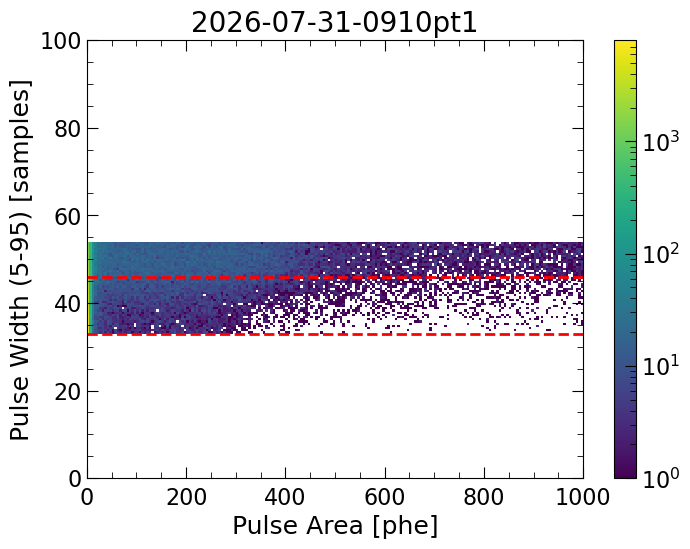

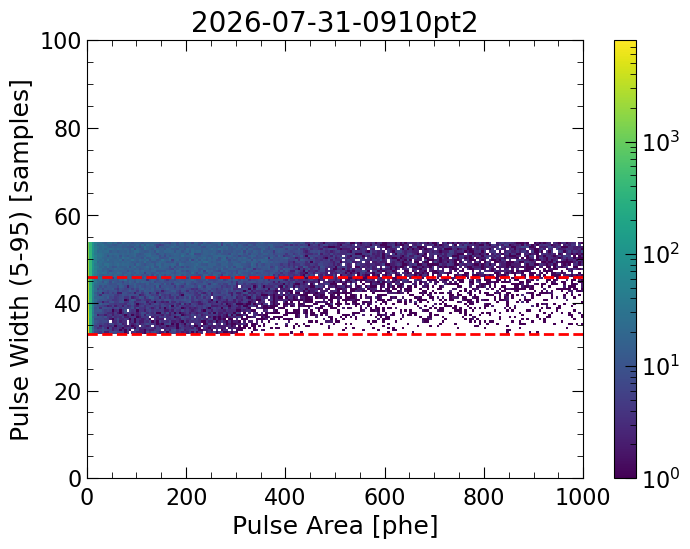

In [17]:
for label in dataset_labels:
    dataset = d[label]
    #Plots for cut verification and checks
    processingFunctions.plot2d(dataset['ss_s2_phe'].flatten(), dataset['ss_s2_width595'].flatten(), (0,1e3), (0, 1e2), x_bins=200, y_bins=200, flag_log=True)
    plt.colorbar()
    #plt.xlim(0, 200)
    plt.xlabel("Pulse Area [phe]")
    plt.ylabel("Pulse Width (5-95) [samples]")
    plt.axhline(y=33, color='red', linestyle="--")
    plt.axhline(y=46, color='red', linestyle="--")
    plt.title(label)
    #plt.ticklabel_format(axis='both', style='sci', scilimits=(3,5))
    plt.show()

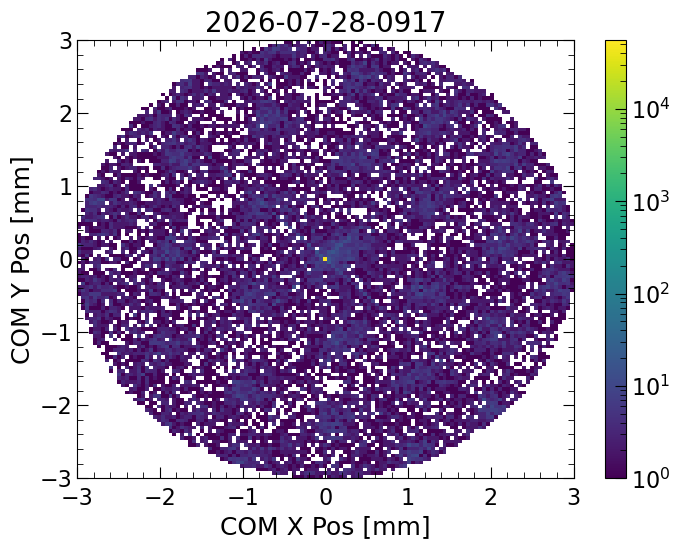

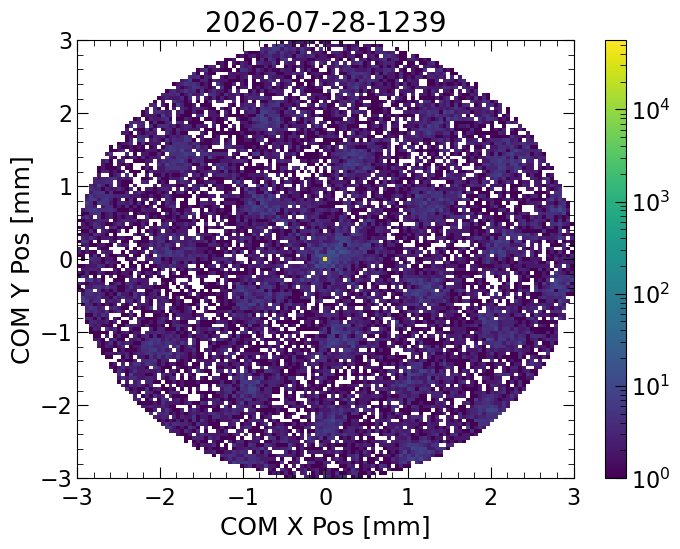

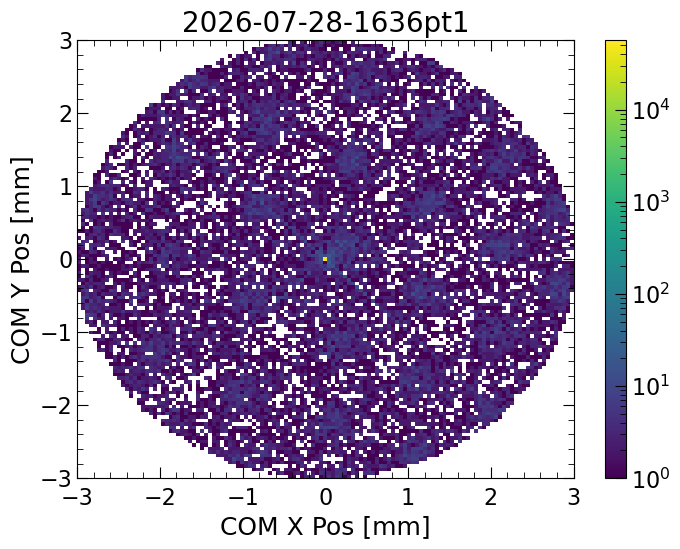

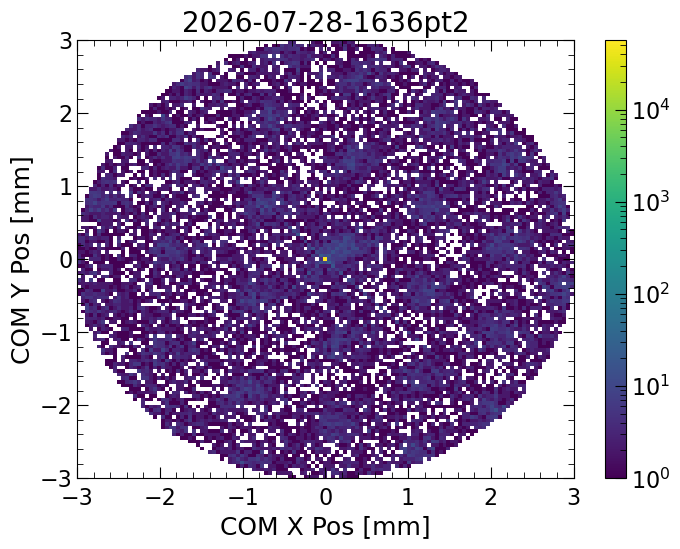

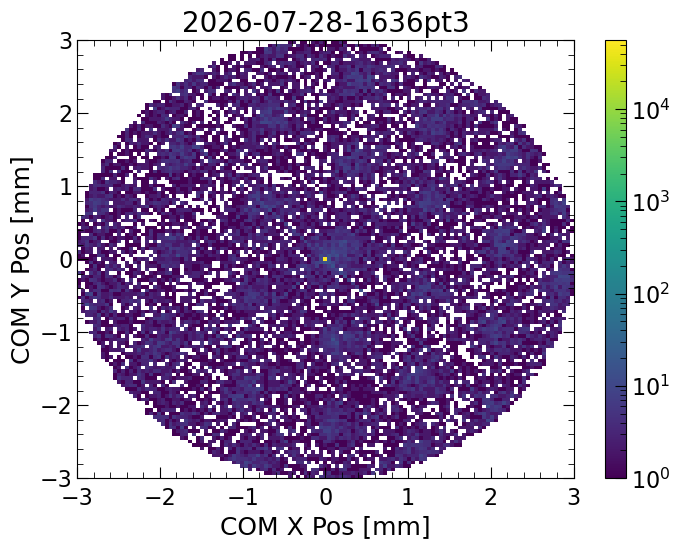

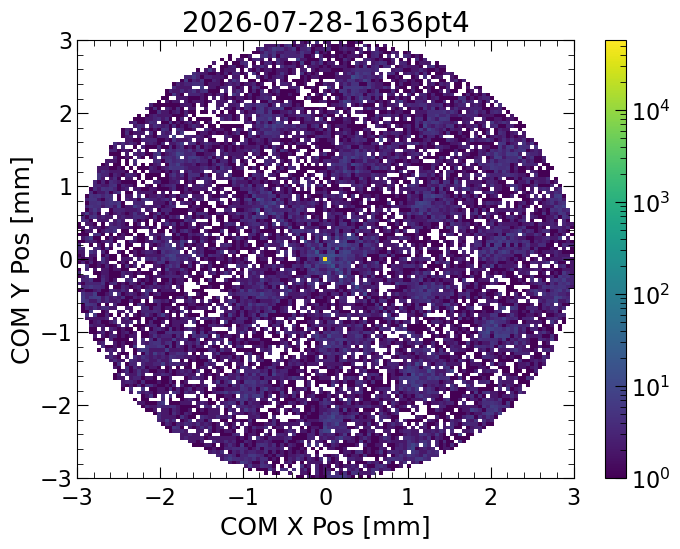

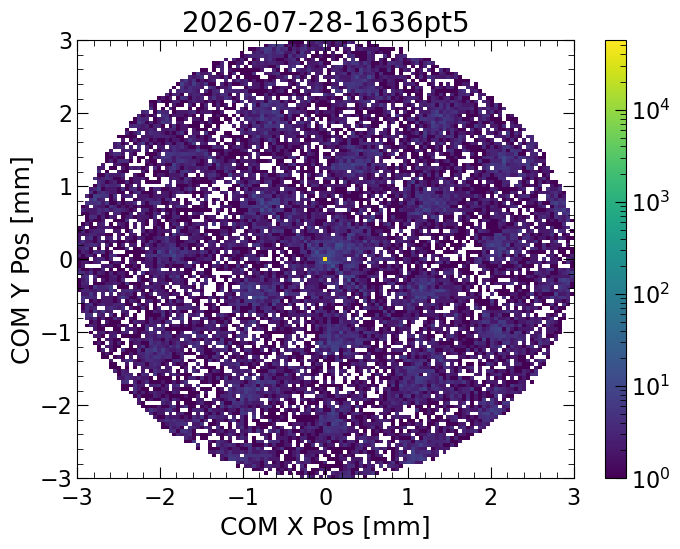

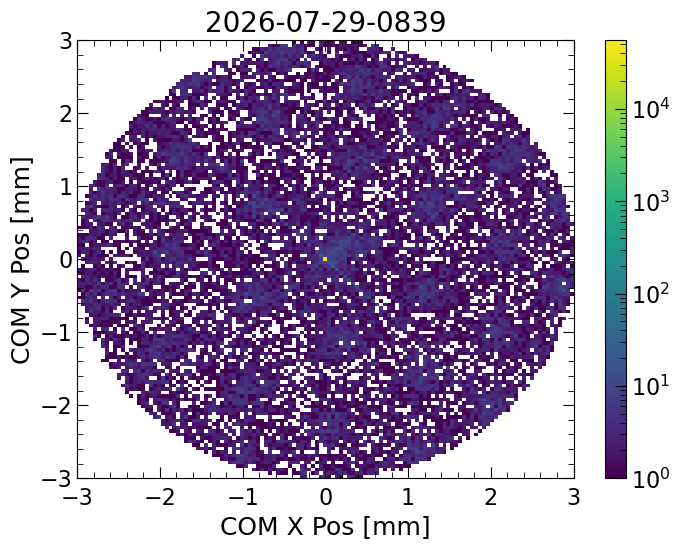

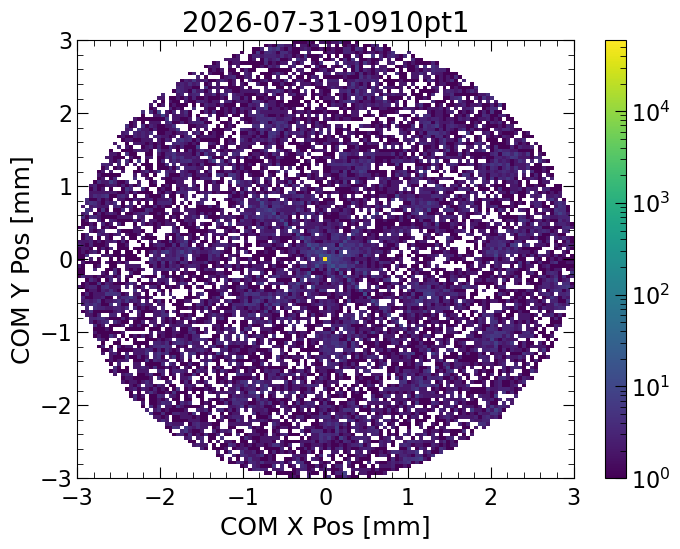

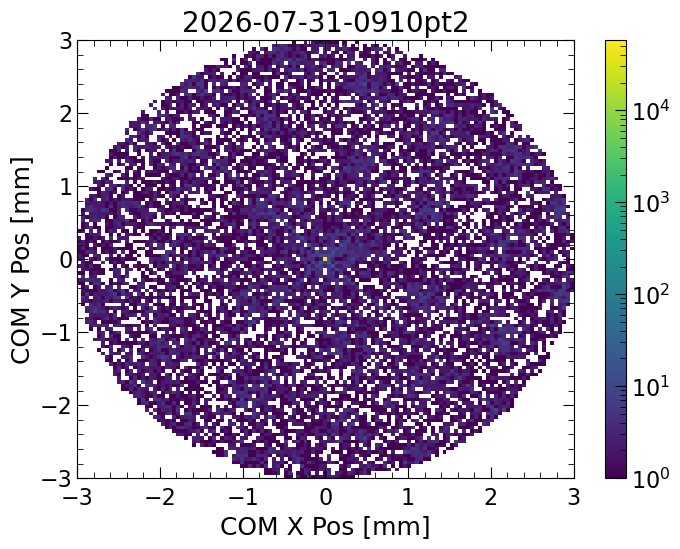

In [9]:
for label in dataset_labels:
    dataset = d[label]
    master_cut = dataset['radial_cut']
    processingFunctions.plot2d(dataset['ss_s2_x_raw'][master_cut], dataset['ss_s2_y_raw'][master_cut], (-3, 3), (-3, 3), x_bins=125, y_bins=125, flag_log=True)
    plt.xlabel("COM X Pos [mm]")
    plt.ylabel("COM Y Pos [mm]")
    plt.title(label)
    plt.colorbar()
    plt.show()

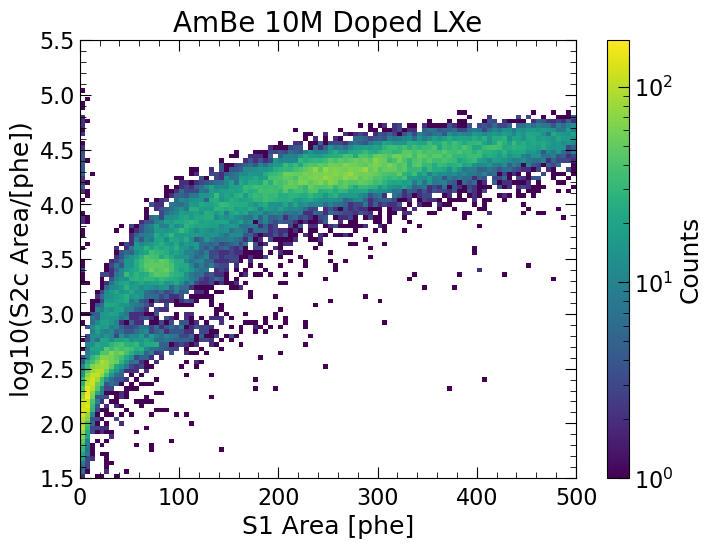

In [15]:
full_s1_area = np.array([])
full_s2_area = np.array([])

for label in dataset_labels:
    dataset = d[label]
    master_cut = dataset['mhf_cut'] & dataset['drift_time_cut'] & dataset['tba_cut'] & dataset['bad_area_cut'] & dataset['radial_cut']
    s1_area_cut = dataset['ss_s1_phe'][master_cut]
    s2_area_cut = (dataset['ss_s2_phe']* np.exp(dataset['ss_s2_drift_time']/1320))[master_cut]
    full_s1_area = np.concatenate((full_s1_area, s1_area_cut))
    full_s2_area = np.concatenate((full_s2_area, s2_area_cut))

processingFunctions.plot2d(full_s1_area, np.log10(full_s2_area), (0,5e2), (1.5, 5.5), x_bins=100, y_bins=100, flag_log=True)

plt.colorbar(label="Counts")
#plt.ticklabel_format(axis='both', style='sci', scilimits=(3,1))
plt.xlabel("S1 Area [phe]")
plt.ylabel("log10(S2c Area/[phe])")
plt.title("AmBe 10M Doped LXe")
plt.show()